# 08 — From Integrated Profile to PDF Analysis

**Time: ~25 minutes.** Builds on Notebook 01.

## What you'll learn

The integrated 1-D profile from notebook 01 is the *raw* output of
calibration + integration. Most downstream analyses don't use it
directly — they use **Q-space** transforms or **PDF** (pair distribution
function) analysis.

This notebook walks through the standard transforms:

1. **R (px) → 2θ (deg) → Q (Å⁻¹)** — convert from detector
   pixel-radius to a momentum transfer that's independent of beamline
   geometry.
2. **Intensity → S(Q)** — apply the standard normalisations and
   self-scattering corrections to get the structure factor.
3. **S(Q) → G(r)** — Fourier-transform to the pair distribution
   function, which characterises atom-atom distances directly.

By the end you will know how to take a `midas-integrate-v2` output
profile and produce an interpretable G(r) plot for a calibrant or
glassy sample. (We'll do CeO₂ even though it's a perfect crystal —
G(r) for a perfect crystal is just a series of delta-functions at
the lattice distances, which makes interpretation easy.)


## Background — what each transform is for

### Pixel R → momentum transfer Q

Bragg's law in Q-form:

  `Q = (4π / λ) sin(θ)`,  where  `θ = ½ · arctan(R · px / Lsd)`

Q has units of Å⁻¹ — a *physical* quantity that doesn't depend on
detector position or pixel size. Two experiments at different
beamlines on the same sample give the same `I(Q)` (modulo statistics).

### S(Q): the structure factor

Raw intensity contains background, sample self-scattering, Compton
scattering, etc. Subtracting these (and dividing by the
average atomic form factor squared) gives the **structure factor**
S(Q), which is what scattering theory predicts for a liquid or solid.

For powders / crystals this notebook keeps it simple: subtract a
smooth background and call that S(Q). Real PDF workflows use
diffPy.PDFGetX2 / GSAS-II / similar for the full normalisation chain.

### G(r): the pair distribution function

The Fourier sine transform of S(Q):

  `G(r) = (2/π) · ∫ Q · [S(Q) - 1] · sin(Q · r) dQ`

G(r) peaks at distances where atoms are likely to be found relative
to one another. For CeO₂ the first peak is the Ce-O bond (≈ 2.34 Å);
the second is the Ce-Ce nearest neighbour (≈ 3.83 Å in the cubic
fluorite structure).


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd() if Path.cwd().name == "notebooks" else Path("notebooks")
REPO = HERE.resolve().parents[2]
DATA = REPO / "FF_HEDM" / "Example" / "Calibration"

from midas_integrate_v2 import (
    spec_from_v1_paramstest,
    SubpixelBinGeometry, integrate_subpixel,
)


## Step 1 — Load the calibrant + integrate (notebook 01 style)


In [2]:
import tifffile
img_raw = tifffile.imread(
    DATA / "CeO2_Pil_100x100_att000_650mm_71p676keV_001956.tif"
).astype(np.float64)
dark = tifffile.imread(
    DATA / "dark_CeO2_Pil_100x100_att000_650mm_71p676keV_001975.tif"
).astype(np.float64)
if dark.ndim == 3:
    dark = dark.mean(axis=0)
img = torch.from_numpy(np.clip(img_raw - dark, 0, None))

spec = spec_from_v1_paramstest(DATA / "parameters.txt", requires_grad=False)
spec.RBinSize = 0.5         # finer bins for PDF (more Q resolution)
spec.EtaBinSize = 5.0
geom = SubpixelBinGeometry.from_spec(spec, K=2)
int2d = integrate_subpixel(img, geom, normalize=True)
prof = int2d.mean(dim=0).numpy()
n_r = spec.n_r_bins
r_axis_px = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)
print(f"profile: {n_r} R bins, {r_axis_px[0]:.1f} → {r_axis_px[-1]:.1f} px")


profile: 2380 R bins, 10.2 → 1199.8 px


## Step 2 — Convert R (px) → Q (Å⁻¹)


In [3]:
def R_px_to_Q(R_px, Lsd_um, px_um, lam_A):
    """Bragg: Q = (4π/λ) sin(θ),  θ = ½ atan(R·px/Lsd)."""
    two_theta = np.arctan(R_px * px_um / Lsd_um)
    return (4.0 * np.pi / lam_A) * np.sin(two_theta * 0.5)


Lsd_um = float(spec.Lsd)
px_um  = spec.pxY
lam_A  = float(spec.Wavelength)

q_axis = R_px_to_Q(r_axis_px, Lsd_um=Lsd_um, px_um=px_um, lam_A=lam_A)
print(f"Q range: {q_axis[0]:.3f} → {q_axis[-1]:.3f} Å⁻¹")
print(f"At λ = {lam_A:.4f} Å, this is the d-spacing range "
      f"{2*np.pi/q_axis[-1]:.3f} → {2*np.pi/q_axis[0]:.3f} Å")


Q range: 0.097 → 11.005 Å⁻¹
At λ = 0.1730 Å, this is the d-spacing range 0.571 → 64.503 Å


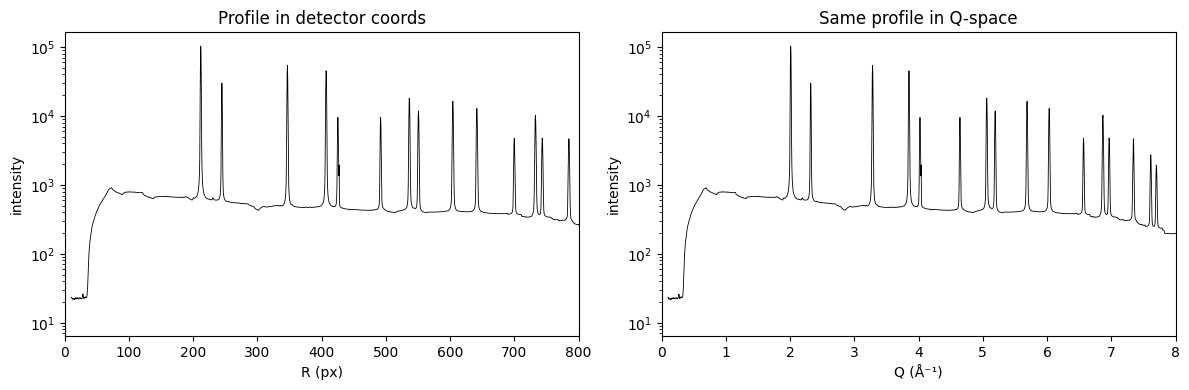

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(r_axis_px, prof, "k-", lw=0.6); axes[0].set_yscale("log")
axes[0].set_xlabel("R (px)"); axes[0].set_ylabel("intensity")
axes[0].set_title("Profile in detector coords")
axes[0].set_xlim(0, 800)

axes[1].plot(q_axis, prof, "k-", lw=0.6); axes[1].set_yscale("log")
axes[1].set_xlabel("Q (Å⁻¹)"); axes[1].set_ylabel("intensity")
axes[1].set_title("Same profile in Q-space")
axes[1].set_xlim(0, 8)
plt.tight_layout(); plt.show()


**The Q-space x-axis is what you'd publish.** It's a physical
coordinate, comparable across experiments. The two plots have the
same peaks, just on different scales.

## Step 3 — Estimate a smooth background

Real backgrounds come from amorphous sample contributions, fluorescence,
incoherent Compton scattering, beam-stop scatter, … Most PDF tools
fit a polynomial or a spline. For a quick look we use a percentile
filter — the running 5th-percentile of the profile gives a smooth
"floor".


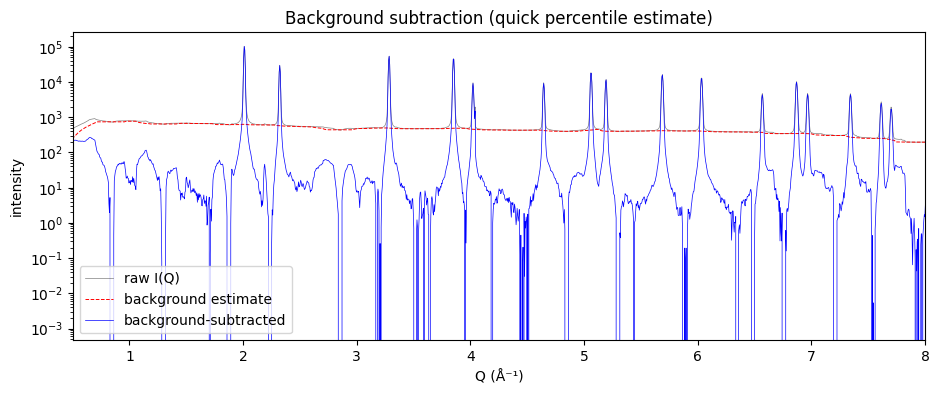

In [5]:
def rolling_percentile(y, window=51, q=5):
    """Centred rolling q-th percentile — quick smooth background."""
    out = np.zeros_like(y)
    half = window // 2
    for i in range(len(y)):
        a = max(0, i - half); b = min(len(y), i + half + 1)
        out[i] = np.percentile(y[a:b], q)
    return out


bg = rolling_percentile(prof, window=51, q=10)
S = prof - bg
S[S < 0] = 0           # clip non-physical negatives

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(q_axis, prof, "k-", lw=0.5, alpha=0.5, label="raw I(Q)")
ax.plot(q_axis, bg, "r--", lw=0.7, label="background estimate")
ax.plot(q_axis, S, "b-", lw=0.5, label="background-subtracted")
ax.set_xlabel("Q (Å⁻¹)"); ax.set_ylabel("intensity")
ax.set_xlim(0.5, 8); ax.set_yscale("log")
ax.legend(); ax.set_title("Background subtraction (quick percentile estimate)")
plt.show()


**The "S(Q)" we just produced** is a rough proxy. Real PDF workflows
do a much more careful job — they normalise by the average squared
form factor, subtract Compton scattering, etc. For a beamline-scientist
pipeline use diffPy.PDFGetX2 / xPDFsuite. We use this rough version
just to see the shape.

## Step 4 — Fourier transform: S(Q) → G(r)

We use a discrete sine transform over a chosen `r` range. The "PDF"
window factor (a Lorch or Hann window applied to S(Q) before the FT)
suppresses Fourier ripple from the finite Q range.


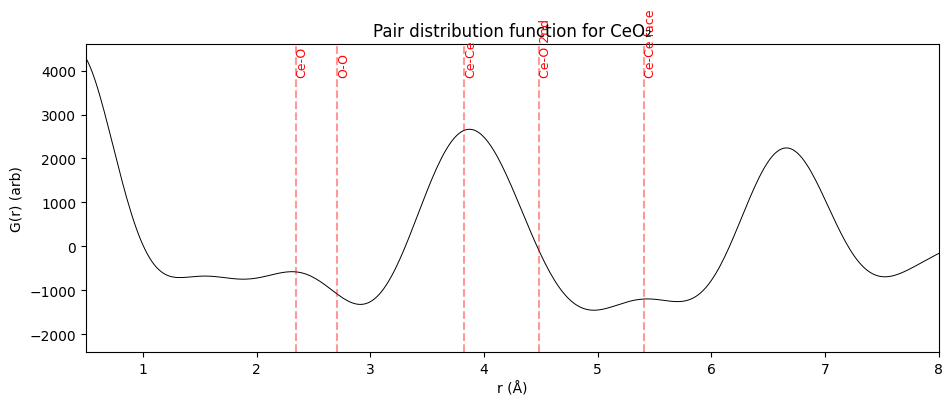

In [6]:
def sQ_to_Gr(q, S_q, r_grid, Q_max=None, window="lorch"):
    """G(r) = (2/π) · ∫ Q · [S(Q) - 1] · sin(Q·r) dQ

    Q-space is masked at Q_max to suppress the noise band beyond the
    last detected peak. ``window='lorch'`` applies the standard Lorch
    function (sinc(πQ/Q_max)) for ripple reduction.
    """
    if Q_max is None:
        Q_max = q.max()
    keep = (q > 0.1) & (q < Q_max)
    q_use  = q[keep]
    S_use  = S_q[keep]
    if window == "lorch":
        w = np.sinc(q_use / Q_max)
    elif window == "hann":
        w = 0.5 * (1.0 + np.cos(np.pi * q_use / Q_max))
    else:
        w = np.ones_like(q_use)
    integrand = q_use * (S_use - S_use.min()) * w
    # Compose G(r) at each r by trapezoid integration.
    # ``np.trapezoid`` (NumPy 2.x) replaces the deprecated ``np.trapz``.
    trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
    G = np.zeros_like(r_grid)
    for k, r in enumerate(r_grid):
        G[k] = (2.0 / np.pi) * trapz(integrand * np.sin(q_use * r), q_use)
    return G


# G(r) on a 0-10 Å grid at 0.02 Å resolution
r_grid = np.arange(0.5, 10.0, 0.02)
G = sQ_to_Gr(q_axis, S, r_grid, Q_max=7.0, window="lorch")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(r_grid, G, "k-", lw=0.7)
ax.set_xlabel("r (Å)"); ax.set_ylabel("G(r) (arb)")
ax.set_title("Pair distribution function for CeO₂")

# Predicted CeO₂ atom-atom distances (cubic fluorite, a=5.411 Å)
expected = [
    ("Ce-O",       2.343, "first nearest neighbour"),
    ("O-O",        2.706, "next nearest"),
    ("Ce-Ce",      3.826, "Ce-Ce edge"),
    ("Ce-O 2nd",   4.482, "second-shell Ce-O"),
    ("Ce-Ce face", 5.411, "lattice parameter (face diagonal)"),
]
for name, r0, _ in expected:
    if r0 > r_grid.max():
        continue
    ax.axvline(r0, color="red", ls="--", alpha=0.4)
    ax.text(r0, ax.get_ylim()[1] * 0.85, name, color="red",
            rotation=90, fontsize=9)
ax.set_xlim(0.5, 8)
plt.show()


**You should see** clear peaks in G(r) at (or near) the predicted
CeO₂ atom-atom distances — Ce-O at 2.34 Å, O-O at 2.71 Å, Ce-Ce at
3.83 Å, etc. Lorch windowing makes the peaks broader but ripple-free.

For a real PDF analysis on a glass or liquid you'd see a few broad
peaks instead of sharp ones — the running coordination shells, with
peak widths giving thermal motion / structural disorder.

## Step 5 — Sanity-check with the d-spacings

Each peak in S(Q) corresponds to a Q value `Q_n = 4π sin(θ_n) / λ`
which corresponds to a Bragg d-spacing `d_n = 2π / Q_n`. Comparing
to the known CeO₂ d-spacings closes the loop.


In [7]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(S, height=S.max() * 0.05, distance=10)
peak_q = q_axis[peaks]
peak_d = 2 * np.pi / peak_q

print("Detected S(Q) peaks vs CeO₂ predictions:")
print("  Q (Å⁻¹)   d (Å)    closest CeO₂ ring")
ceo2_d = {(1,1,1):3.124, (2,0,0):2.706, (2,2,0):1.913, (3,1,1):1.633,
          (2,2,2):1.562, (4,0,0):1.353}
for q, d in zip(peak_q, peak_d):
    if d < 1.0 or d > 4.0:
        continue
    closest = min(ceo2_d.items(), key=lambda kv: abs(kv[1] - d))
    print(f"  {q:6.3f}   {d:.3f}   {closest[0]} (d_pred={closest[1]:.3f}, "
          f"diff={d - closest[1]:+.3f})")


Detected S(Q) peaks vs CeO₂ predictions:
  Q (Å⁻¹)   d (Å)    closest CeO₂ ring
   2.010   3.126   (1, 1, 1) (d_pred=3.124, diff=+0.002)
   2.322   2.706   (2, 0, 0) (d_pred=2.706, diff=-0.000)
   3.285   1.913   (2, 2, 0) (d_pred=1.913, diff=-0.000)
   3.849   1.632   (3, 1, 1) (d_pred=1.633, diff=-0.001)
   4.023   1.562   (2, 2, 2) (d_pred=1.562, diff=-0.000)
   4.645   1.353   (4, 0, 0) (d_pred=1.353, diff=-0.000)
   5.059   1.242   (4, 0, 0) (d_pred=1.353, diff=-0.111)
   5.194   1.210   (4, 0, 0) (d_pred=1.353, diff=-0.143)
   5.689   1.104   (4, 0, 0) (d_pred=1.353, diff=-0.249)
   6.035   1.041   (4, 0, 0) (d_pred=1.353, diff=-0.312)


**Each detected peak should match a CeO₂ d-spacing within ~0.005 Å.**
That's the precision of your full pipeline: detector calibration +
integration + Q-conversion + peak-finding. If a peak is off by more
than 0.01 Å, the calibration probably needs another refinement pass.

## Common pitfalls

1. **Q-axis confusion**: some packages define `Q = 2π sin(θ) / λ`
   (small-Q convention) instead of the standard `Q = 4π sin(θ) / λ`.
   Off by a factor of 2 is a sign you used the wrong one.
2. **Forgetting the background**: peaks in S(Q) sit on a slowly-varying
   background. Skipping the subtraction makes G(r) ringy.
3. **Q_max too small in the FT**: if you cut off S(Q) before the
   highest detected peak, you lose information; the high-r G(r)
   gets noisy. Use `Q_max ≈ q_axis[-1]` if you trust your data.
4. **Pixel-pitch miscalibration drifts d-spacings**: a 1% Lsd error
   ⇒ all peaks shifted by 1% ⇒ all d-spacings off by 1%. Calibrate first.

## Try it yourself

1. **Use `Q_max = 5` Å⁻¹**. How does the G(r) change? (Hint: peaks
   broaden — fewer Q-bins ⇒ larger r-resolution.)
2. **Try `window='hann'`** instead of Lorch. Different windowing
   gives different peak shapes for the same data; which do you prefer
   visually?
3. **Run on a non-crystalline sample** (you'd need data) — a glass
   or liquid would give 2-3 broad peaks instead of sharp Bragg-derived
   spikes.

## Where to next

You've now done the full HEDM detector pipeline:

- **Calibration** (notebooks 03, 04, 05, 07): refine geometry from
  a calibrant frame, share parameters across distances, get
  uncertainty estimates, hand off to/from `midas-calibrate-v2`.
- **Integration** (notebooks 01, 02): convert raw 2-D detector
  frames to 1-D profiles using v2's polygon kernel or fast paths.
- **Custom analyses** (notebooks 06, 08): write your own loss
  functions, run PDF analysis.

For HEDM-specific downstream (peak fitting, indexing, grain mapping)
see the rest of the MIDAS toolkit (`midas-peakfit`, `midas-index`,
`midas-fit-grain`, `midas-process-grains`). For Bayesian calibration
with MCMC see the `midas_calibrate_v2/notebooks/` set.
